In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [8]:
from google.colab import files

uploaded = files.upload()

Saving Lab-Task-02.jpg to Lab-Task-02.jpg


In [9]:
# Read image
img = cv2.imread("Lab-Task-02.jpg")

if img is None:
    print("Image not loaded. Check the file name.")
else:
    print("Image loaded successfully.")

Image loaded successfully.


In [10]:
# Brightness
bright_img = cv2.convertScaleAbs(img, alpha=1.0, beta=50)
dark_img = cv2.convertScaleAbs(img, alpha=1.0, beta=-50)

In [11]:
# Contrast
high_contrast = cv2.convertScaleAbs(img, alpha=1.5, beta=0)
low_contrast = cv2.convertScaleAbs(img, alpha=0.6, beta=0)

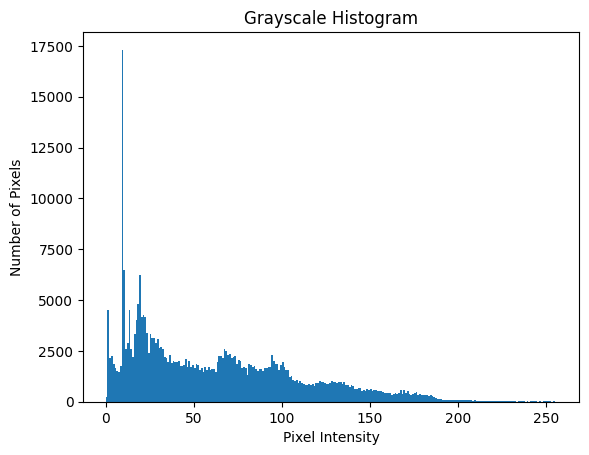

In [12]:
# Grayscale and histogram
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.show()

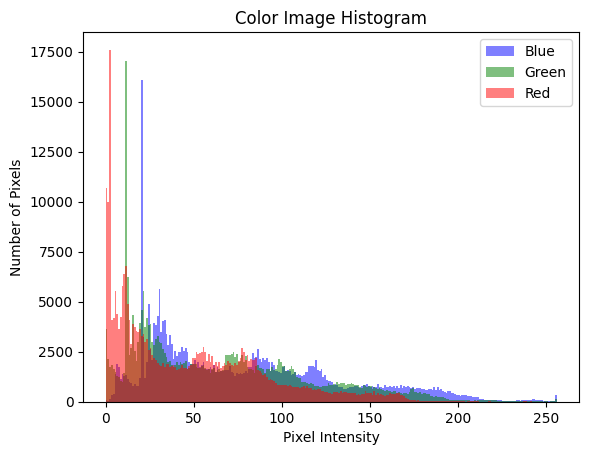

In [13]:
# Color image histogram
b, g, r = cv2.split(img)

plt.hist(b.ravel(), bins=256, range=[0, 256],
         color='blue', alpha=0.5, label='Blue')
plt.hist(g.ravel(), bins=256, range=[0, 256],
         color='green', alpha=0.5, label='Green')
plt.hist(r.ravel(), bins=256, range=[0, 256],
         color='red', alpha=0.5, label='Red')

plt.title("Color Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.legend()
plt.show()

In [14]:
# Add salt-and-pepper noise
noisy = img.copy()
amount = 0.02
num_pixels = int(amount * img.shape[0] * img.shape[1])

In [15]:
# Add white pixels
y = np.random.randint(0, img.shape[0], num_pixels)
x = np.random.randint(0, img.shape[1], num_pixels)
noisy[y, x] = 255

In [16]:
# Add black pixels
y = np.random.randint(0, img.shape[0], num_pixels)
x = np.random.randint(0, img.shape[1], num_pixels)
noisy[y, x] = 0

In [17]:
# Filters
mean_filtered = cv2.blur(noisy, (5, 5))
gaussian_filtered = cv2.GaussianBlur(noisy, (5, 5), 0)
median_filtered = cv2.medianBlur(noisy, 5)

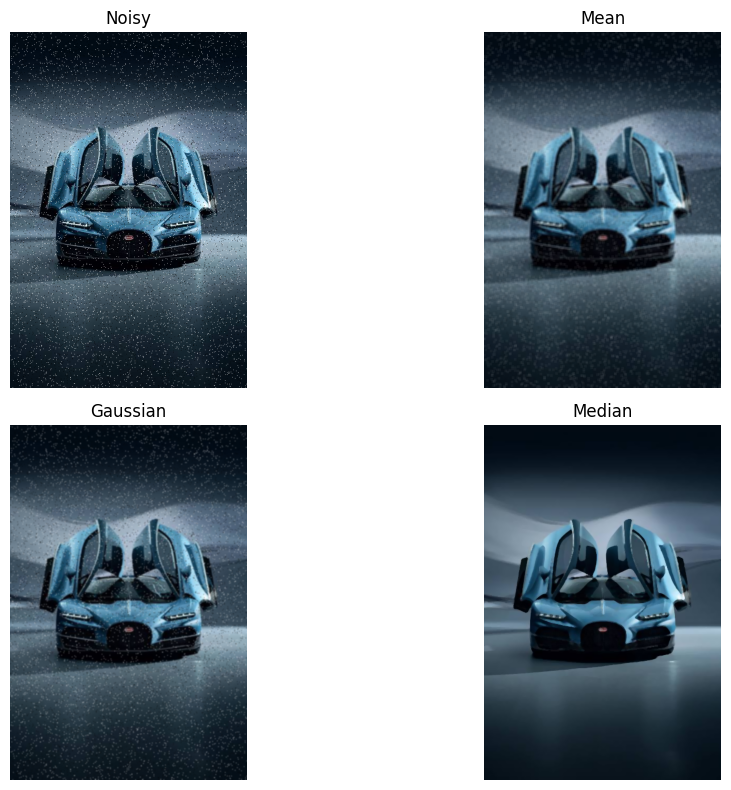

In [18]:
# Compare results
images = [noisy, mean_filtered, gaussian_filtered, median_filtered]
titles = ["Noisy", "Mean", "Gaussian", "Median"]

plt.figure(figsize=(12, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Save final filter outputs
cv2.imwrite("mean_filtered.jpg", mean_filtered)
cv2.imwrite("gaussian_filtered.jpg", gaussian_filtered)
cv2.imwrite("median_filtered.jpg", median_filtered)

print("NoiseFix Mini completed.")

NoiseFix Mini completed.
